# Experiment Results Analysis

This notebook shows a comparison of three evaluator strategies (UCB, PPO, DPO) for ProTeGi-style prompt optimization across FinanceBench, FinDoc-RAG, and FinQA datasets at three compute budget levels, with 5 replications per configuration.

In [1]:
import json
import pathlib
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

RESULTS_DIR = pathlib.Path("experiments")

DATASET_MAP = {"FB": "FinanceBench", "FD": "FinDoc", "FQ": "FinQA"}
EVALUATORS = ["UCB", "PPO", "DPO"]
BUDGETS = [1, 2, 3]
COLORS = {"UCB": "#1f77b4", "PPO": "#ff7f0e", "DPO": "#2ca02c"}

def parse_results(filepath):
    text = filepath.read_text()
    lines = text.strip().split("\n")
    rounds = []
    i = 1
    while i < len(lines):
        if lines[i].startswith("======== ROUND"):
            try:
                round_num = int(lines[i].split()[-1])
                time_s = float(lines[i+1].replace("s", ""))
                est_scores = json.loads(lines[i+2])
                true_scores = json.loads(lines[i+3])
                rounds.append({
                    "round": round_num,
                    "time_s": time_s,
                    "best_true": max(true_scores),
                    "top_pick_true": true_scores[0],
                })
                i += 4
            except (json.JSONDecodeError, ValueError, IndexError):
                i += 1
        else:
            i += 1
    # Some files have extra rounds from checkpoint resumes (old corrupted
    # rounds followed by new clean ones). Use only the last 7.
    if len(rounds) > 7:
        rounds = rounds[-7:]
    return rounds

# Parse all result files
data = defaultdict(list)
round_data = defaultdict(lambda: defaultdict(list))

for f in sorted(RESULTS_DIR.glob("F[BDQ]_*.txt")):
    name = f.stem
    parts = name.split("_")
    prefix = parts[0]
    evaluator = parts[1].upper()
    budget = int(parts[2][1])
    dataset = DATASET_MAP.get(prefix)
    if dataset is None:
        continue

    rounds = parse_results(f)
    if len(rounds) < 7:
        continue

    baseline = rounds[0]["best_true"]
    final = rounds[-1]["best_true"]
    peak = max(r["best_true"] for r in rounds)
    data[(dataset, evaluator, budget)].append({
        "baseline": baseline,
        "final": final,
        "peak": peak,
        "gain": final - baseline,
    })
    for r in rounds:
        round_data[(dataset, evaluator, budget)][r["round"]].append(r["best_true"])

total = sum(len(v) for v in data.values())
datasets_found = sorted(set(k[0] for k in data.keys()))
print(f"Loaded {total} completed experiments across {datasets_found}")

Loaded 135 completed experiments across ['FinDoc', 'FinQA', 'FinanceBench']


## Summary Table (Mean +/- Std across 5 seeds)

In [2]:
print(f"{'Dataset':<14} {'Eval':<6} {'Budget':<8} {'Baseline':>10} {'Final (mean +/- std)':>24} {'Gain (mean +/- std)':>24} {'N':>4}")
print("-" * 94)

for dataset in ["FinanceBench", "FinDoc", "FinQA"]:
    has_data = False
    for budget in BUDGETS:
        for evaluator in EVALUATORS:
            key = (dataset, evaluator, budget)
            if key not in data:
                continue
            has_data = True
            entries = data[key]
            baselines = [e["baseline"] for e in entries]
            finals = [e["final"] for e in entries]
            gains = [e["gain"] for e in entries]
            n = len(entries)
            print(f"{dataset:<14} {evaluator:<6} {budget:<8} "
                  f"{np.mean(baselines):>10.1%} "
                  f"{np.mean(finals):>10.1%} +/- {np.std(finals):>5.1%} "
                  f"{np.mean(gains):>+8.1%} +/- {np.std(gains):>5.1%} "
                  f"{n:>4}")
    if has_data:
        print()

Dataset        Eval   Budget     Baseline     Final (mean +/- std)      Gain (mean +/- std)    N
----------------------------------------------------------------------------------------------
FinanceBench   UCB    1             10.0%      30.0% +/-  6.7%   +20.0% +/- 12.5%    5
FinanceBench   PPO    1             10.0%      30.0% +/- 12.5%   +20.0% +/-  6.7%    5
FinanceBench   DPO    1              6.7%      30.0% +/- 12.5%   +23.3% +/-  8.2%    5
FinanceBench   UCB    2             23.3%      33.3% +/- 21.1%   +10.0% +/- 13.3%    5
FinanceBench   PPO    2             23.3%      33.3% +/- 21.1%   +10.0% +/- 13.3%    5
FinanceBench   DPO    2             20.0%      33.3% +/- 21.1%   +13.3% +/- 12.5%    5
FinanceBench   UCB    3             36.7%      40.0% +/- 22.6%    +3.3% +/- 12.5%    5
FinanceBench   PPO    3             30.0%      40.0% +/- 13.3%   +10.0% +/-  8.2%    5
FinanceBench   DPO    3             36.7%      40.0% +/-  8.2%    +3.3% +/- 16.3%    5

FinDoc         UCB    1 

## Final Accuracy by Dataset and Budget (with error bars)

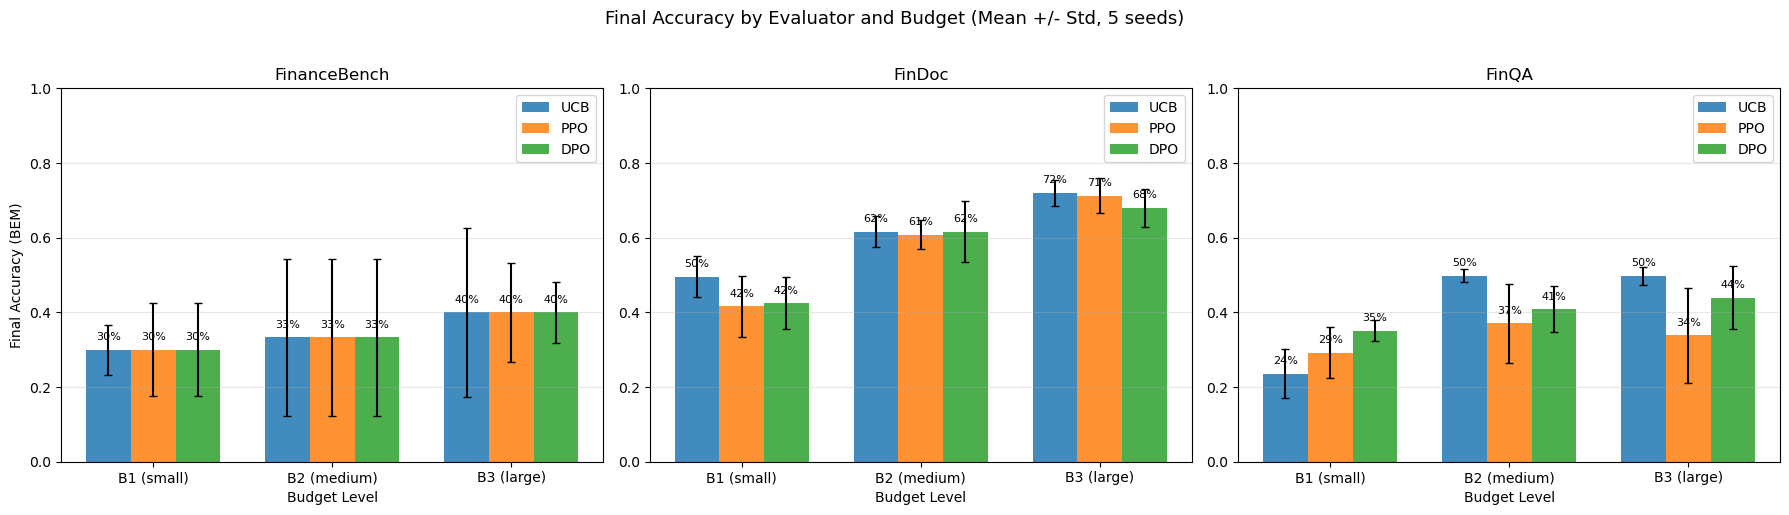

In [3]:
datasets_to_plot = [d for d in ["FinanceBench", "FinDoc", "FinQA"] if any(k[0] == d for k in data.keys())]
fig, axes = plt.subplots(1, len(datasets_to_plot), figsize=(6 * len(datasets_to_plot), 5), sharey=False)
if len(datasets_to_plot) == 1:
    axes = [axes]

for idx, dataset in enumerate(datasets_to_plot):
    ax = axes[idx]
    x = np.arange(len(BUDGETS))
    width = 0.25
    for i, ev in enumerate(EVALUATORS):
        means, stds = [], []
        for b in BUDGETS:
            key = (dataset, ev, b)
            if key in data:
                finals = [e["final"] for e in data[key]]
                means.append(np.mean(finals))
                stds.append(np.std(finals))
            else:
                means.append(0)
                stds.append(0)
        bars = ax.bar(x + i * width, means, width, yerr=stds, label=ev,
                      color=COLORS[ev], capsize=3, alpha=0.85)
        for bar, val in zip(bars, means):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f"{val:.0%}", ha="center", va="bottom", fontsize=8)
    ax.set_title(dataset)
    ax.set_xlabel("Budget Level")
    ax.set_xticks(x + width)
    ax.set_xticklabels(["B1 (small)", "B2 (medium)", "B3 (large)"])
    ax.set_ylim(0, 1.0)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

axes[0].set_ylabel("Final Accuracy (BEM)")
fig.suptitle("Final Accuracy by Evaluator and Budget (Mean +/- Std, 5 seeds)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("final_accuracy_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()

## Accuracy Gain Over Baseline

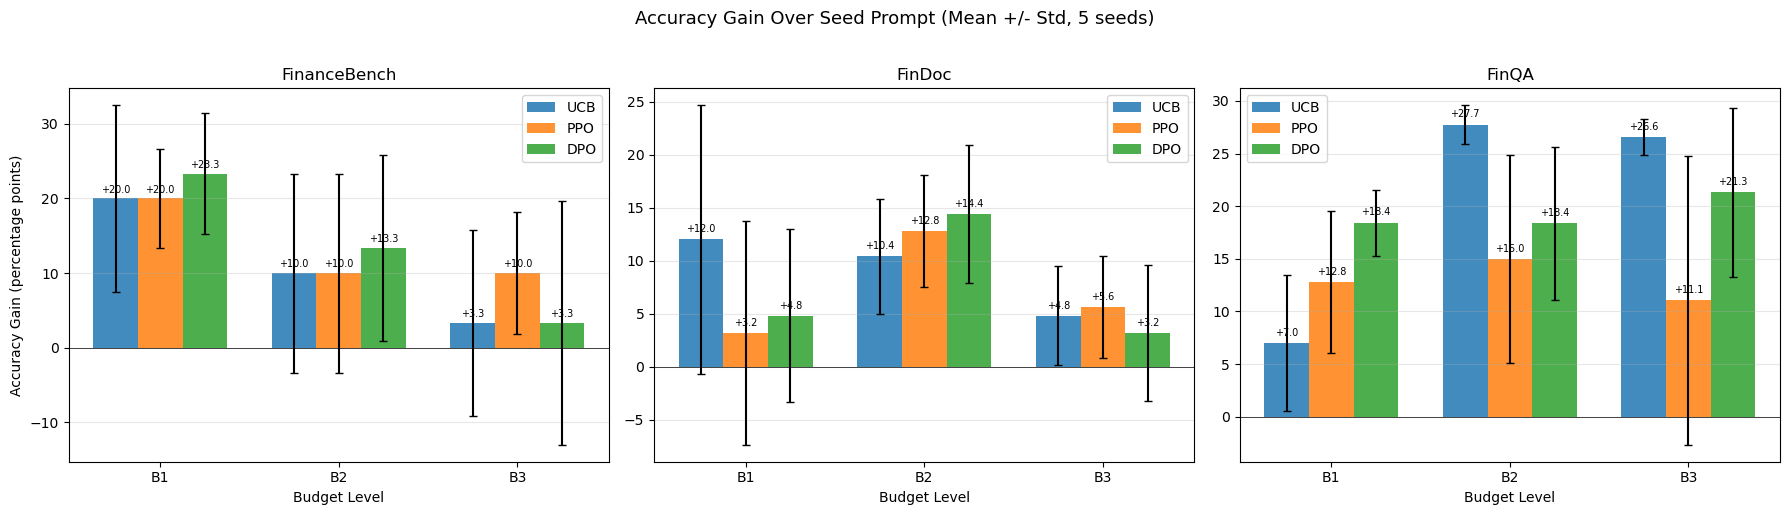

In [4]:
fig, axes = plt.subplots(1, len(datasets_to_plot), figsize=(6 * len(datasets_to_plot), 5), sharey=False)
if len(datasets_to_plot) == 1:
    axes = [axes]

for idx, dataset in enumerate(datasets_to_plot):
    ax = axes[idx]
    x = np.arange(len(BUDGETS))
    width = 0.25
    for i, ev in enumerate(EVALUATORS):
        means, stds = [], []
        for b in BUDGETS:
            key = (dataset, ev, b)
            if key in data:
                gains = [e["gain"] * 100 for e in data[key]]
                means.append(np.mean(gains))
                stds.append(np.std(gains))
            else:
                means.append(0)
                stds.append(0)
        bars = ax.bar(x + i * width, means, width, yerr=stds, label=ev,
                      color=COLORS[ev], capsize=3, alpha=0.85)
        for bar, val in zip(bars, means):
            if val != 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        f"{val:+.1f}", ha="center", va="bottom", fontsize=7)
    ax.set_title(dataset)
    ax.set_xlabel("Budget Level")
    ax.set_xticks(x + width)
    ax.set_xticklabels(["B1", "B2", "B3"])
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

axes[0].set_ylabel("Accuracy Gain (percentage points)")
fig.suptitle("Accuracy Gain Over Seed Prompt (Mean +/- Std, 5 seeds)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("gain_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()

## Accuracy Progression by Round (Mean +/- Std across seeds)

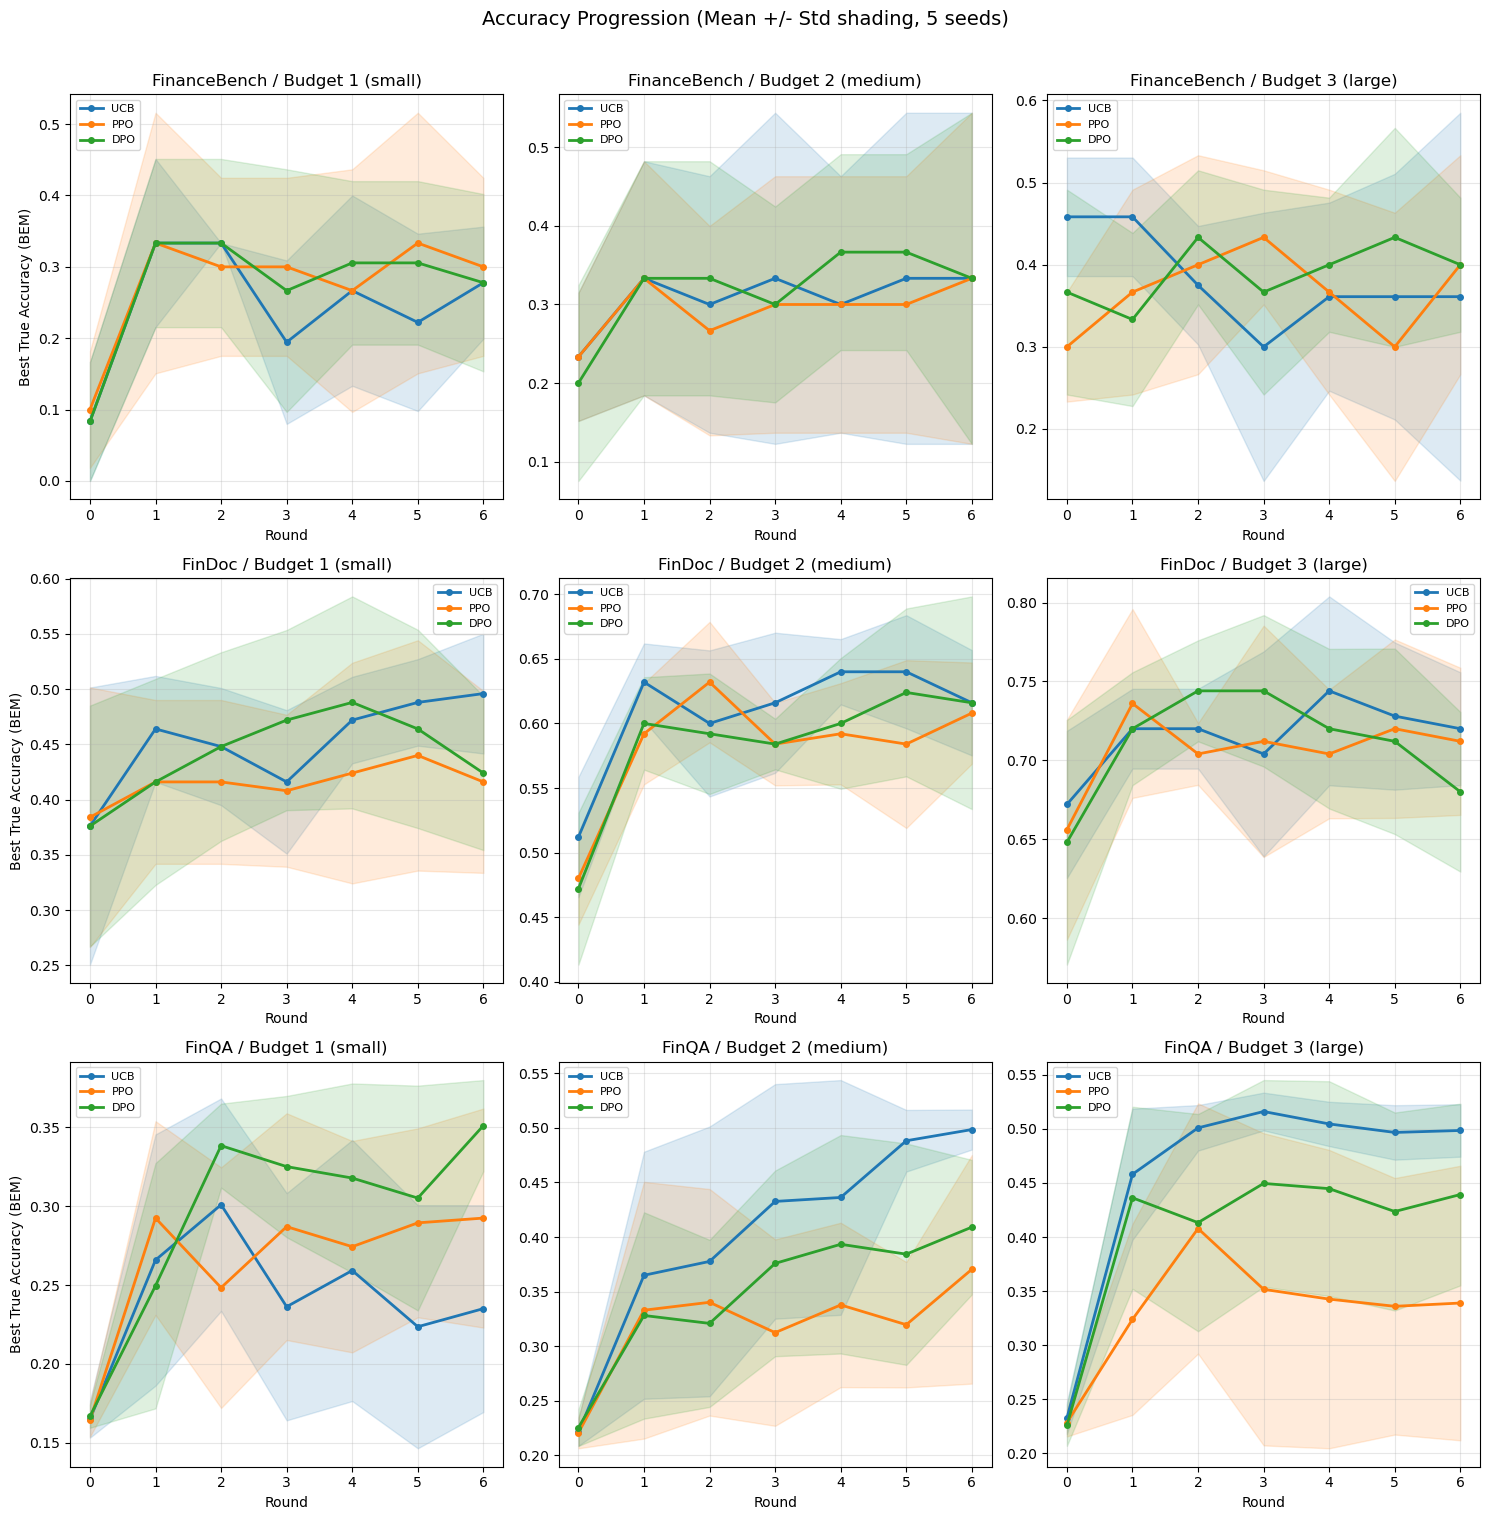

In [5]:
fig, axes = plt.subplots(len(datasets_to_plot), 3, figsize=(15, 5 * len(datasets_to_plot)), sharey=False)
if len(datasets_to_plot) == 1:
    axes = [axes]

budget_labels = {1: "Budget 1 (small)", 2: "Budget 2 (medium)", 3: "Budget 3 (large)"}

for row, dataset in enumerate(datasets_to_plot):
    for col, budget in enumerate(BUDGETS):
        ax = axes[row][col]
        for ev in EVALUATORS:
            key = (dataset, ev, budget)
            if key not in round_data:
                continue
            rd = round_data[key]
            rounds_sorted = sorted(rd.keys())
            means = [np.mean(rd[r]) for r in rounds_sorted]
            stds = [np.std(rd[r]) for r in rounds_sorted]
            ax.plot(rounds_sorted, means, marker="o", label=ev,
                    color=COLORS[ev], linewidth=2, markersize=4)
            ax.fill_between(rounds_sorted,
                            [m - s for m, s in zip(means, stds)],
                            [m + s for m, s in zip(means, stds)],
                            alpha=0.15, color=COLORS[ev])
        ax.set_title(f"{dataset} / {budget_labels[budget]}")
        ax.set_xlabel("Round")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[row][0].set_ylabel("Best True Accuracy (BEM)")

fig.suptitle("Accuracy Progression (Mean +/- Std shading, 5 seeds)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("progression_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings (135 experiments: 3 datasets x 3 evaluators x 3 budgets x 5 seeds)

### FinanceBench

All three evaluators converge to similar final accuracies (~30-40%) regardless of evaluator choice. There is high variance across seeds (std of 8-22%) reflects the small test set (6 examples). No evaluator has a clear advantage on this dataset.

### FinDoc-RAG

Cleaner results with lower variance (std of 3-8%). UCB is consistently the best at budget 1 (49.6% vs 41-42% for PPO/DPO). At budget 2, all three evaluators are nearly tied (~61%). At budget 3, UCB leads slightly (72.0%) over PPO (71.2%) and DPO (68.0%). Budget is the dominant factor.

### FinQA

UCB is the strongest evaluator, reaching 49.8% at both budget 2 and budget 3.
DPO is consistently second (35.1% at B1, 40.9% at B2, 43.9% at B3). PPO is
the most variable (std of 10-13% at budgets 2-3). All three evaluators show
clear improvement over the seed prompt baseline (~16-23%).

### Cross-Dataset Summary

1. **Budget matters most on smaller datasets.** On FinanceBench and FinDoc,
   higher budgets consistently improve results. On FinQA, budget 2 and
   budget 3 produce similar gains for UCB (~27-28 pp), suggesting
   diminishing returns at scale.

2. **No single evaluator dominates.** UCB is strongest on FinDoc and FinQA.
   DPO is competitive on FinQA across all budgets. On FinanceBench, all
   three are equivalent.

3. **Variance is dataset-dependent.** FinDoc has the lowest variance
   (std 3-8%), FinanceBench the highest (8-22%) due to its tiny test set,
   and FinQA falls in between (2-13%).

4. **Evaluator choice matters more on larger datasets.** On FinanceBench
   (6 test examples), evaluator choice is irrelevant. On FinDoc (25 test
   examples) and FinQA (331 test examples), evaluator differences become
   significant and consistent across seeds.